# cVAE for fMRI Functional Connectivity (AAL ROIs)

**What this notebook does.**  
Trains a **conditional variational autoencoder (cVAE)** to model functional-connectivity (FC) vectors derived from AAL ROI spheres. The condition is the **subject identity** (one-hot), allowing the model to capture subject-specific structure while learning a shared latent space.

**Data + preprocessing**
- Expects FC matrices at: `data/data_FC/<SUBJECT>/<SESSION>/conn_matrix_w_sphere.mat` (key: `correlation_matrix`).
- Selects one of four seed/ROI rows via `row_idx` (0–3) and flattens/cleans to an FC feature vector.
- Loads study metadata from `data/SubConds.xlsx`.
- One-hot encodes **subject IDs** → conditioning vector.
- Produces tensors and builds a `DataLoader` (batch size 32).

**Model**
- Architecture: `CVAE(input_dim, cond_dim, latent_dim=10, hidden_dim=64)`.
- Encoder: FC(64, ReLU) → linear heads for **μ** and **log σ²**; reparameterization trick for sampling.
- Decoder is conditioned on the subject one-hot vector to reconstruct FC vectors.

**Training**
- Optimizer: **Adam**, learning rate **3e-4**.
- Loss: reconstruction + KL divergence (standard VAE objective).
- Default schedule: **500 epochs** on the selected ROI.
- Utilities: training loop, loss tracking, and plotting helpers are imported from `utils/*`.

**Reproducibility**
- Global seeding for **Python**, **NumPy**, and **PyTorch** (including CUDA), with deterministic cuDNN settings; default seed **42**.


**How to run**
1. Place data under `data/` as above.
2. Open the notebook and set `use_roi = {0|1|2|3}` to pick the seed/ROI.
3. Run all cells. Training logs and (optional) plots will be produced.
4. To adjust capacity, change `latent_dim`, `hidden_dim`, `NUM_EPOCH`, or `LR`.

**Notes**
- If you see “File not found” warnings, verify the `data_FC` folder layout and the `.mat` key name.
- The subject-weighted variant can be used as a **robustness check** for class imbalance; the manuscript reports the **raw** version.


In [1]:
# Auto-Reload for Fast Iteration
%load_ext autoreload
%autoreload 2

# --- Add project root (the dir that contains 'utils/') to sys.path ---
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "utils").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT)) # insert project root at the front of the search list
print("Project root:", ROOT)  # sanity check

# Import custom functions from utils package
from utils.models import VAE, CVAE
from utils.train_utils import (
    train_vae,
    loss_function,
    get_latent_mu,
    get_latent_mu_cvae,
    compute_condition_distances,
    compute_per_session_dist_to_null
)
from utils.data_utils import (
    load_all_fc_data,
    preprocess_for_torch
)
from utils.utils_plotting import (
    plot_vae_losses,
    plot_latent_embedding_by_condition_and_subject,
    plot_subject_distance_comparison
)
from utils.bootstrap import *   # common imports, DEVICE

Project root: /Users/liuq13/project-nodeap-fmri-cvae


In [2]:
### set seeds for Python, Numpy, PyTorch to make the code reproducible
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)               # Python random
    np.random.seed(seed)            # NumPy
    torch.manual_seed(seed)         # CPU seed
    torch.cuda.manual_seed(seed)    # Current GPU seed
    torch.cuda.manual_seed_all(seed) # All GPUs

    # Ensures deterministic behavior (but may slow down training)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Example usage
set_seed(42)


In [3]:
DATA_DIR = (ROOT / "data").resolve()
sub_cond_path     = DATA_DIR / "SubConds.xlsx"
base_nifti_folder = DATA_DIR / "data_FC"
condition_map = {'N': 0, 'S': 1, 'C': 2}

In [4]:
# Load and preprocess

# Select ROI index:
# 0 = aOFC seed
# 1 = aOFC target
# 2 = pOFC seed
# 3 = pOFC target

use_roi = 0  # Select ROI index (0–3), corresponding to the four seed/ROIs analyzed in this study
all_corr_data, all_tms_type, all_subject_id, all_stimloc, all_session = load_all_fc_data(sub_cond_path, 
                                                               base_nifti_folder, 
                                                               mat_filename='conn_matrix_w_sphere.mat',
                                                               key_name='correlation_matrix',row_idx=use_roi)
# One-hot encode subject ID as condition
subject_arr = np.array(all_subject_id).reshape(-1, 1)
subject_encoder = OneHotEncoder(sparse_output=False, drop=None)
subject_ohe = subject_encoder.fit_transform(subject_arr)  # shape: [n_samples, n_subjects]

# Convert to torch tensors
X_tensor = preprocess_for_torch(all_corr_data)  
subject_cond_tensor = torch.tensor(subject_ohe, dtype=torch.float32)
dataset = TensorDataset(X_tensor, subject_cond_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_30/S3D2/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_44/S1D1/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_83/S3D1/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_87/D0/conn_matrix_w_sphere.mat
[WARN] File not found: /Users/liuq13/project-nodeap-fmri-cvae/data/data_FC/NODEAP_88/D0/conn_matrix_w_sphere.mat
Columns with NaN: 14 / 116
Tensor shape after preprocessing: torch.Size([331, 102])


In [5]:
X_tensor.shape

torch.Size([331, 102])

In [6]:
subject_cond_tensor.shape

torch.Size([331, 48])

In [7]:
all_tms_type.shape

(331,)

In [8]:
# Set up model, optimizer, and device
input_dim = X_tensor.shape[1]
cond_dim = subject_cond_tensor.shape[1]
latent_dim = 10
hidden_dim = 64 
NUM_EPOCH = 500
LR = 3e-4
model = CVAE(input_dim=input_dim, cond_dim=cond_dim, latent_dim=latent_dim, hidden_dim=hidden_dim).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
total_loss_hist, recon_loss_hist, kld_loss_hist = train_vae(model, dataloader, optimizer, device=DEVICE, epochs=NUM_EPOCH)


===== Epoch 1 =====


Epoch 1/500: 100%|████████████████████████████████████████████████| 11/11 [00:00<00:00, 273.45it/s]


Epoch 1, Loss: 103.8722, Recon: 103.5721, KL: 0.3001

===== Epoch 2 =====


Epoch 2/500: 100%|███████████████████████████████████████████████| 11/11 [00:00<00:00, 1132.96it/s]


Epoch 2, Loss: 103.4558, Recon: 103.2086, KL: 0.2471

===== Epoch 3 =====


...

Epoch 498, Loss: 27.8826, Recon: 18.5237, KL: 9.3589

===== Epoch 499 =====


Epoch 499/500: 100%|█████████████████████████████████████████████| 11/11 [00:00<00:00, 1275.96it/s]


Epoch 499, Loss: 28.0041, Recon: 18.5766, KL: 9.4274

===== Epoch 500 =====


Epoch 500/500: 100%|█████████████████████████████████████████████| 11/11 [00:00<00:00, 1261.93it/s]


Epoch 500, Loss: 28.3278, Recon: 18.7831, KL: 9.5446


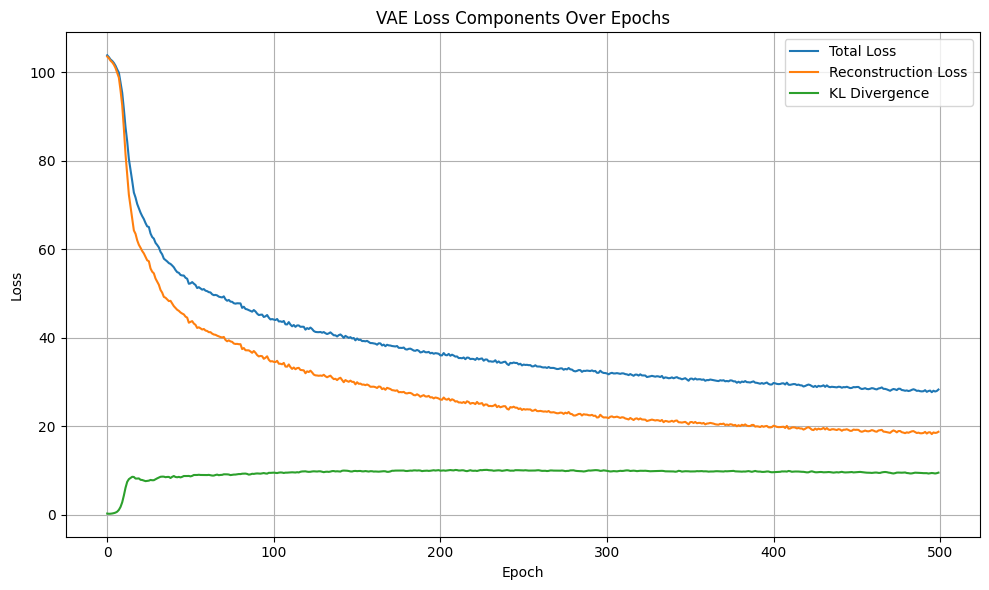

In [9]:
plot_vae_losses(total_loss_hist, recon_loss_hist, kld_loss_hist)

dim of latent mu: (331, 10)


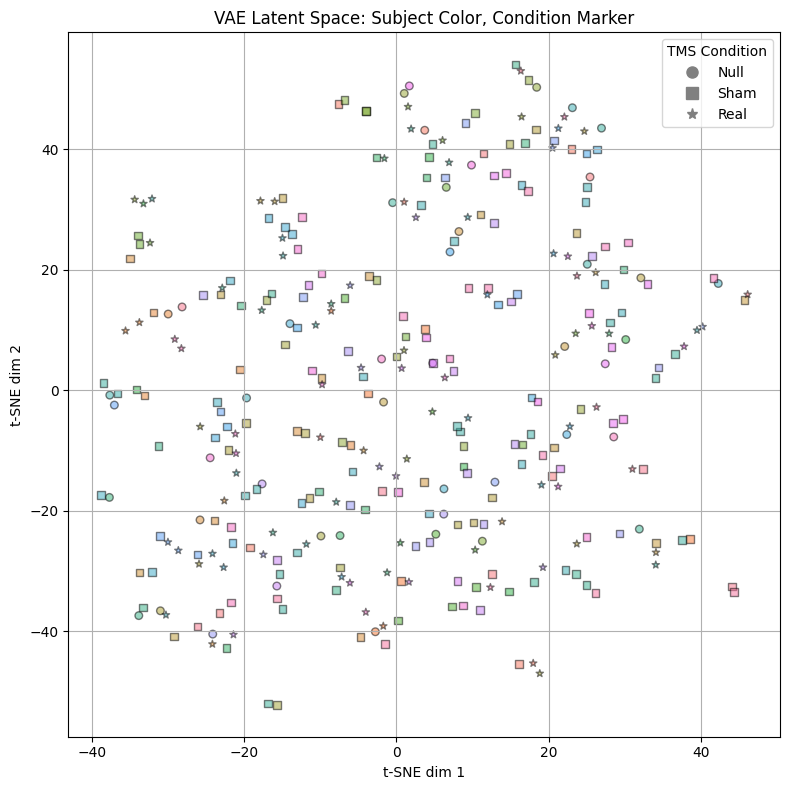

In [10]:
mu_all = get_latent_mu_cvae(model, X_tensor, subject_cond_tensor, device=DEVICE)
# 2d-TSNE
z_2d = TSNE(n_components=2, perplexity=8).fit_transform(mu_all)
plot_latent_embedding_by_condition_and_subject(z_2d, all_tms_type, all_subject_id)

Paired t-test: t = -2.410, p = 0.0201


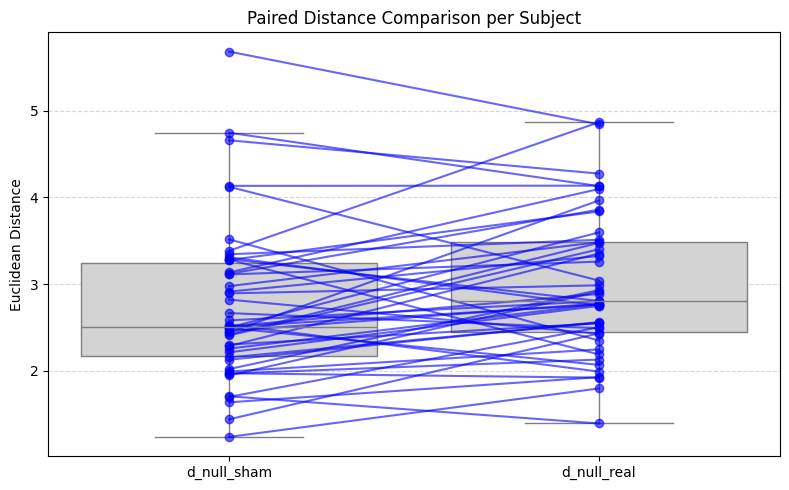

In [11]:
df = compute_condition_distances(mu_all, all_tms_type, all_subject_id, condition_map)

# Paired t-test
t_stat, p_val_t = ttest_rel(df["d_null_sham"], df["d_null_real"])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val_t:.4f}")
plot_subject_distance_comparison(df)

In [12]:
output_dir = ROOT / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)   
output_filename = output_dir / f"dist_summary_roi_{use_roi}.csv"
df.to_csv(output_filename, index=False)

df_session_dists = compute_per_session_dist_to_null(mu_all, all_subject_id, all_tms_type, all_session)
output_filename = output_dir / f"session_distances_roi_{use_roi}.csv"
df_session_dists.to_csv(output_filename, index=False)